# Import The Required Library

In [1]:
import sklearn
print(sklearn.__version__)

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Other plots (example)

from src.exp import (
    ExperimentConfig, ExperimentFacade,
    DataReadConfig, PlotManager
)

1.8.0


## 1. Prioritise the Use of Scikit Learn Intelex Patch over Regular Scikit-learn Library

In [2]:
try:
    from sklearnex import patch_sklearn
    patch_sklearn()
    print("Intel sklearn patch enabled")
except ImportError:
    print("sklearnex not installed; using standard sklearn")


sklearnex not installed; using standard sklearn


## 2. Inform The Dataset Location

In [3]:
data_cfg = DataReadConfig(
    root_dir="Dataset/data",        # the root directory to search for CSV files
    recursive=True,                 # whether to search for files in subdirectories
    exclude_filenames=["cclass.csv", "unclean focus.csv","unclean cclass.csv","focus.csv"],  # the excluded files
    add_source_column=False,        # enable this to make additional column filled with the original taken filenames
)

## 3. Put the Configuration of Optuna

In [4]:
cfg = ExperimentConfig(
    outer_folds=5,              # number of outer folds for nested cross-validation
    inner_folds=5,              # number of inner folds for hyperparameter tuning
    n_trials=40,                # number of hyperparameter optimization trials
    seed=42,                    # random seed for reproducibility
    log_target=True             # whether to log-transform the target variable (if applicable)
)

## 4. List All the Regression Models

In [5]:
# Define the list of models to evaluate
# Note: The actual implementation of these models should be defined in the ExperimentFacade or 
# imported from relevant libraries.

models = ["LinearRegression", "DecisionTree", "RandomForest", "XGBoost", "NeuralNetwork"] # "SVR", "XGBoost", "NeuralNetwork"]

## 5. Initialize the experiment facade with the specified configurations and model list

In [6]:
exp = ExperimentFacade.from_folder(
    data_cfg=data_cfg,                      # configuration for reading the data
    target="price",                         # the target variable for prediction    
    cfg=cfg,                                # the experiment configuration
    model_names=models,                     # the list of model names to evaluate
    hparam_json="config/hyperparams.json"   # the path to the JSON file containing hyperparameter search spaces
)


[schema]
  numerical cols: ['year', 'mileage', 'tax', 'mpg', 'engineSize']
  categorical cols: ['model', 'transmission', 'fuelType']
  target col: ['price']
  mapping: {'model': 'model', 'year': 'year', 'price': 'price', 'transmission': 'transmission', 'mileage': 'mileage', 'fuelType': 'fuelType', 'tax': 'tax', 'mpg': 'mpg', 'engineSize': 'engineSize'}


## 6. Run the experiment (this will perform nested cross-validation, hyperparameter tuning, and model evaluation)

In [7]:
# Run the experiment (this will perform nested cross-validation, hyperparameter tuning, and model evaluation)
# Dataset summary + correlation plot (saved to outputs/figures)
info = exp.data_info(out_dir="outputs/csvs", prefix="dataset")
print(info)


<class 'pandas.DataFrame'>
RangeIndex: 99187 entries, 0 to 99186
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   model         99187 non-null  category
 1   year          99187 non-null  int64   
 2   price         99187 non-null  int64   
 3   transmission  99187 non-null  category
 4   mileage       99187 non-null  int64   
 5   fuelType      99187 non-null  category
 6   tax           99187 non-null  int64   
 7   mpg           99187 non-null  float64 
 8   engineSize    99187 non-null  float64 
dtypes: category(3), float64(2), int64(4)
memory usage: 4.9 MB
None


## 7. Generate and save the correlation heatmap

[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/correlation/correlation_heatmap.png
Saved correlation heatmap to: outputs/figures/correlation/correlation_heatmap.png


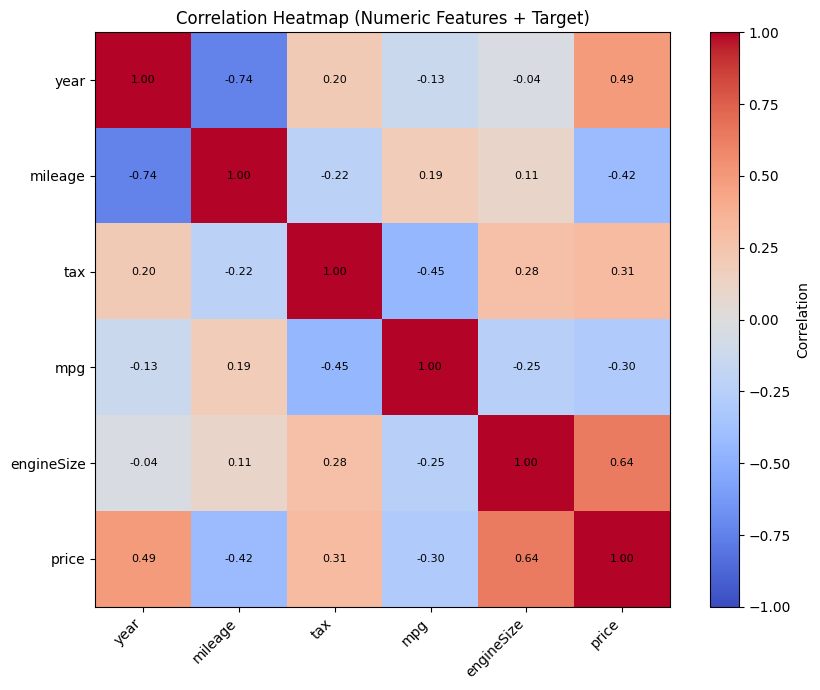

In [8]:
# Generate and save the correlation heatmap
corr_path = exp.correlation_plot(out_dir="outputs/figures/correlation", 
                                 filename="correlation_heatmap.png")

print(f"Saved correlation heatmap to: {corr_path}")

## 8. Run the experiment (this will perform nested cross-validation, hyperparameter tuning, and model evaluation)


In [9]:
results = exp.run()

[I 2026-04-11 01:58:52,312] A new study created in memory with name: LinearRegression_OuterFold_1_residual_cfg_base
[I 2026-04-11 01:58:57,252] Trial 0 finished with value: 1842.5249137136684 and parameters: {}. Best is trial 0 with value: 1842.5249137136684.
[I 2026-04-11 01:58:59,912] Trial 1 finished with value: 1842.5249137136684 and parameters: {}. Best is trial 0 with value: 1842.5249137136684.
[I 2026-04-11 01:59:02,549] Trial 2 finished with value: 1842.5249137136684 and parameters: {}. Best is trial 0 with value: 1842.5249137136684.
[I 2026-04-11 01:59:05,160] Trial 3 finished with value: 1842.5249137136684 and parameters: {}. Best is trial 0 with value: 1842.5249137136684.
[I 2026-04-11 01:59:08,691] Trial 4 finished with value: 1842.5249137136684 and parameters: {}. Best is trial 0 with value: 1842.5249137136684.
[I 2026-04-11 01:59:11,750] Trial 5 finished with value: 1842.5249137136684 and parameters: {}. Best is trial 0 with value: 1842.5249137136684.
[I 2026-04-11 01:59:

496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 313us/step
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 280us/step
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 284us/step
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 334us/step
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 266us/step


[I 2026-04-11 02:54:13,025] Trial 0 finished with value: 514467.5562492401 and parameters: {'optimizer': 'adamW', 'n_layers': 2, 'units_layer_1': 93, 'units_layer_2': 182, 'units_layer_3': 120, 'units_layer_4': 95, 'activation': 'relu', 'learning_rate': 0.008912031574631267, 'momentum': 0.4442189556872475, 'weight_decay': 2.6333841844193604e-06}. Best is trial 0 with value: 514467.5562492401.


496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 305us/step
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 308us/step
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 292us/step
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 291us/step
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 301us/step


[I 2026-04-11 02:57:13,618] Trial 1 finished with value: 2512.3616522773614 and parameters: {'optimizer': 'sgd', 'n_layers': 3, 'units_layer_1': 90, 'units_layer_2': 156, 'units_layer_3': 123, 'units_layer_4': 63, 'activation': 'sigmoid', 'learning_rate': 0.009308155018643535, 'momentum': 0.21940831436629465, 'weight_decay': 1.955409609247652e-06}. Best is trial 1 with value: 2512.3616522773614.


...

496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 249us/step
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 242us/step
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 250us/step
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 237us/step
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 243us/step


[I 2026-04-11 09:30:23,179] Trial 9 finished with value: 1425.0113220307146 and parameters: {'optimizer': 'adam', 'n_layers': 1, 'units_layer_1': 183, 'units_layer_2': 136, 'units_layer_3': 237, 'units_layer_4': 171, 'activation': 'sigmoid', 'learning_rate': 0.0008791823343586808, 'momentum': 0.3732354151549603, 'weight_decay': 3.3448981376367476e-06}. Best is trial 5 with value: 1359.0831754864607.


496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 407us/step


[I 2026-04-11 09:31:15,855] Trial 10 pruned. 


620/620 ━━━━━━━━━━━━━━━━━━━━ 0s 271us/step
[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/hyperparameters/best_hyperparameters.json
[final fit] LinearRegression
[saved] LinearRegression
[saved] LinearRegression ensemble top3
[final fit] DecisionTree
[saved] DecisionTree
[saved] DecisionTree+ElasticNet
[saved] DecisionTree+Huber
[saved] DecisionTree+PseudoHuber
[saved] DecisionTree ensemble top3
[final fit] RandomForest
[saved] RandomForest
[saved] RandomForest+ElasticNet
[saved] RandomForest+Huber
[saved] RandomForest+PseudoHuber
[saved] RandomForest ensemble top3
[final fit] XGBoost
[saved] XGBoost
[saved] XGBoost+ElasticNet
[saved] XGBoost+Huber
[saved] XGBoost+PseudoHuber
[saved] XGBoost ensemble top3
[final fit] NeuralNetwork
[saved] NeuralNetwork
[saved] NeuralNetwork ensemble top3


## 9. Save the results to a CSV file

In [10]:
results.to_csv("outputs/csvs/experiment_results.csv", index=False)

## 10. Display the experiment summary (this will include performance metrics for each model and fold)

In [11]:
display(exp.summary())

,model,R2_mean,R2_std,MAE_mean,MAE_std,MedAE_mean,MedAE_std,MSE_mean,MSE_std,RMSE_mean,RMSE_std
0,DecisionTree,0.947015,0.004777,1284.564100,20.977425,801.957289,13.403884,5.155763e+06,4.504636e+05,2268.843307,100.705935
1,DecisionTree+ElasticNet,0.947033,0.004778,1284.716853,20.911955,801.773077,13.791613,5.153990e+06,4.506138e+05,2268.451106,100.744807
2,DecisionTree+Huber,0.947028,0.004767,1284.191780,20.963612,801.494555,14.879842,5.154434e+06,4.493552e+05,2268.559168,100.454733
3,DecisionTree+PseudoHuber,0.947563,0.004401,1280.186754,15.008215,799.439825,12.191988,5.102984e+06,4.223503e+05,2257.379631,95.005086
4,LinearRegression,-7.981107,19.871458,1827.732931,207.394523,1106.970456,8.353696,8.790174e+08,1.945051e+09,15625.140632,28170.738699
5,NeuralNetwork,0.948752,0.007439,1328.366908,64.259652,853.821777,65.630189,4.990808e+06,7.470749e+05,2229.134262,164.955306
6,RandomForest,0.959471,0.003362,1133.608924,28.101011,726.758290,16.178567,3.944784e+06,3.311553e+05,1984.748215,83.354356
7,RandomForest+ElasticNet,0.959539,0.003399,1133.912797,28.214816,726.741367,15.160861,3.938128e+06,3.347015e+05,1983.036394,84.367644
8,RandomForest+Huber,0.957120,0.004926,1154.964419,13.546272,735.384968,8.282815,4.173480e+06,4.798907e+05,2040.175514,118.130750
9,RandomForest+PseudoHuber,0.961363,0.004407,1128.428626,16.448138,726.284264,9.470179,3.760864e+06,4.348629e+05,1936.666040,112.854954


## 11. Access the model summary DataFrame

In [12]:
model_summary = exp.summary()["model"]

## 12. Perform significance testing comparing all models against the baseline (e.g., "XGBoost+PseudoHuber")

In [13]:
for metric in ["R2", "MAE", "MedAE", "MSE", "RMSE"]:
    display(exp.significance(
        metric=metric,                              # the evaluation metric to compare (e.g., R2, MAE, RMSE)
        baseline="XGBoost+PseudoHuber",             # the baseline model to compare against (e.g., "XGBoost+PseudoHuber")
        models=model_summary.to_list()              # the list of models to include in the significance test (e.g., all models in the summary
    ))

,metric,baseline,model,paired_t_p,wilcoxon_p,n_outer_folds
2,R2,XGBoost+PseudoHuber,DecisionTree+Huber,0.000017,0.0625,5
1,R2,XGBoost+PseudoHuber,DecisionTree+ElasticNet,0.000017,0.0625,5
0,R2,XGBoost+PseudoHuber,DecisionTree,0.000017,0.0625,5
3,R2,XGBoost+PseudoHuber,DecisionTree+PseudoHuber,0.000026,0.0625,5
8,R2,XGBoost+PseudoHuber,RandomForest+Huber,0.001316,0.0625,5
6,R2,XGBoost+PseudoHuber,RandomForest,0.003513,0.0625,5
7,R2,XGBoost+PseudoHuber,RandomForest+ElasticNet,0.003536,0.0625,5
5,R2,XGBoost+PseudoHuber,NeuralNetwork,0.005806,0.0625,5
10,R2,XGBoost+PseudoHuber,XGBoost,0.025642,0.0625,5
11,R2,XGBoost+PseudoHuber,XGBoost+ElasticNet,0.073221,0.0625,5


,metric,baseline,model,paired_t_p,wilcoxon_p,n_outer_folds
3,MAE,XGBoost+PseudoHuber,DecisionTree+PseudoHuber,0.000003,0.0625,5
1,MAE,XGBoost+PseudoHuber,DecisionTree+ElasticNet,0.000013,0.0625,5
0,MAE,XGBoost+PseudoHuber,DecisionTree,0.000013,0.0625,5
2,MAE,XGBoost+PseudoHuber,DecisionTree+Huber,0.000014,0.0625,5
5,MAE,XGBoost+PseudoHuber,NeuralNetwork,0.000835,0.0625,5
8,MAE,XGBoost+PseudoHuber,RandomForest+Huber,0.001230,0.0625,5
4,MAE,XGBoost+PseudoHuber,LinearRegression,0.001334,0.0625,5
9,MAE,XGBoost+PseudoHuber,RandomForest+PseudoHuber,0.021229,0.0625,5
7,MAE,XGBoost+PseudoHuber,RandomForest+ElasticNet,0.038090,0.1250,5
6,MAE,XGBoost+PseudoHuber,RandomForest,0.038421,0.1250,5


,metric,baseline,model,paired_t_p,wilcoxon_p,n_outer_folds
4,MedAE,XGBoost+PseudoHuber,LinearRegression,5.947622e-08,0.0625,5
3,MedAE,XGBoost+PseudoHuber,DecisionTree+PseudoHuber,2.148136e-04,0.0625,5
0,MedAE,XGBoost+PseudoHuber,DecisionTree,2.762038e-04,0.0625,5
1,MedAE,XGBoost+PseudoHuber,DecisionTree+ElasticNet,3.264332e-04,0.0625,5
2,MedAE,XGBoost+PseudoHuber,DecisionTree+Huber,3.772844e-04,0.0625,5
5,MedAE,XGBoost+PseudoHuber,NeuralNetwork,8.829953e-03,0.0625,5
8,MedAE,XGBoost+PseudoHuber,RandomForest+Huber,1.556762e-02,0.0625,5
9,MedAE,XGBoost+PseudoHuber,RandomForest+PseudoHuber,4.016390e-02,0.0625,5
7,MedAE,XGBoost+PseudoHuber,RandomForest+ElasticNet,9.456001e-02,0.1250,5
6,MedAE,XGBoost+PseudoHuber,RandomForest,1.044546e-01,0.1250,5


,metric,baseline,model,paired_t_p,wilcoxon_p,n_outer_folds
2,MSE,XGBoost+PseudoHuber,DecisionTree+Huber,0.000017,0.0625,5
1,MSE,XGBoost+PseudoHuber,DecisionTree+ElasticNet,0.000017,0.0625,5
0,MSE,XGBoost+PseudoHuber,DecisionTree,0.000017,0.0625,5
3,MSE,XGBoost+PseudoHuber,DecisionTree+PseudoHuber,0.000031,0.0625,5
8,MSE,XGBoost+PseudoHuber,RandomForest+Huber,0.001387,0.0625,5
6,MSE,XGBoost+PseudoHuber,RandomForest,0.003994,0.0625,5
7,MSE,XGBoost+PseudoHuber,RandomForest+ElasticNet,0.004027,0.0625,5
5,MSE,XGBoost+PseudoHuber,NeuralNetwork,0.006064,0.0625,5
10,MSE,XGBoost+PseudoHuber,XGBoost,0.022504,0.0625,5
11,MSE,XGBoost+PseudoHuber,XGBoost+ElasticNet,0.067986,0.0625,5


,metric,baseline,model,paired_t_p,wilcoxon_p,n_outer_folds
2,RMSE,XGBoost+PseudoHuber,DecisionTree+Huber,0.000003,0.0625,5
1,RMSE,XGBoost+PseudoHuber,DecisionTree+ElasticNet,0.000004,0.0625,5
0,RMSE,XGBoost+PseudoHuber,DecisionTree,0.000004,0.0625,5
3,RMSE,XGBoost+PseudoHuber,DecisionTree+PseudoHuber,0.000015,0.0625,5
8,RMSE,XGBoost+PseudoHuber,RandomForest+Huber,0.000790,0.0625,5
7,RMSE,XGBoost+PseudoHuber,RandomForest+ElasticNet,0.004069,0.0625,5
6,RMSE,XGBoost+PseudoHuber,RandomForest,0.004097,0.0625,5
5,RMSE,XGBoost+PseudoHuber,NeuralNetwork,0.004193,0.0625,5
10,RMSE,XGBoost+PseudoHuber,XGBoost,0.021649,0.0625,5
11,RMSE,XGBoost+PseudoHuber,XGBoost+ElasticNet,0.065433,0.0625,5


### a. Display the significance results

In [14]:
#display(sig)

### 13. Example of plotting the performance of models (e.g., R2 scores) using the PlotManager

In [15]:
pm = PlotManager("outputs/figures/metrics")

### a. Generate and save point range plots for each metric

[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/metrics/point_range_r2.png
[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/metrics/point_range_mae.png
[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/metrics/point_range_medae.png
[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/metrics/point_range_mse.png
[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/metrics/point_range_rmse.png


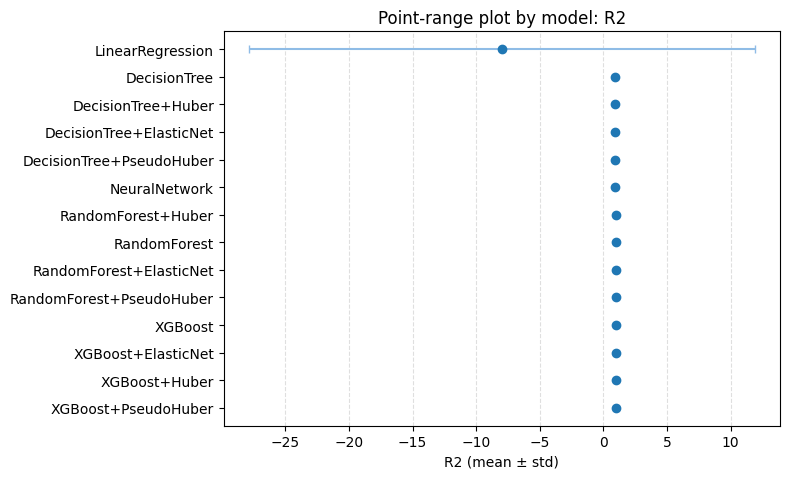

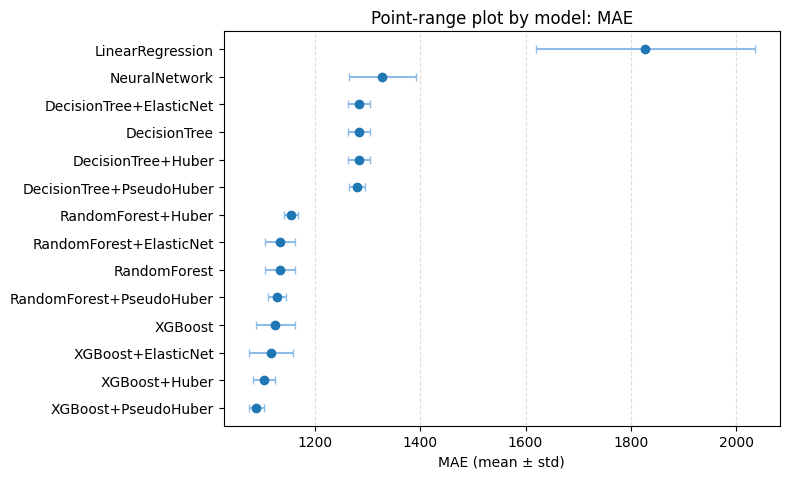

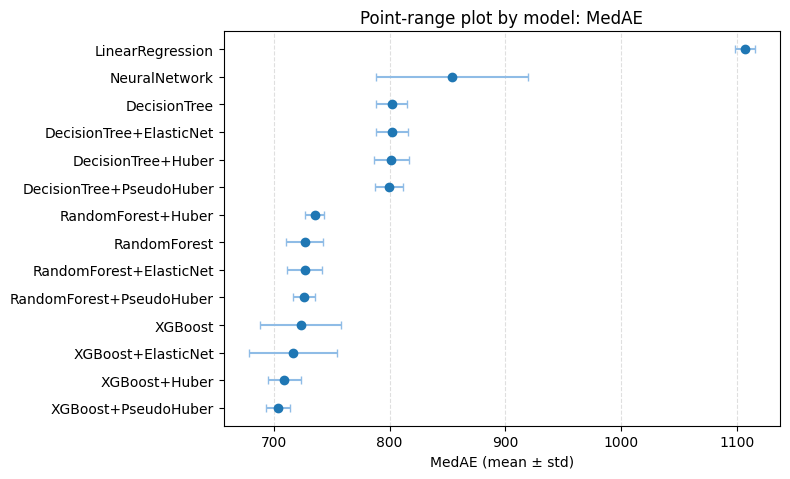

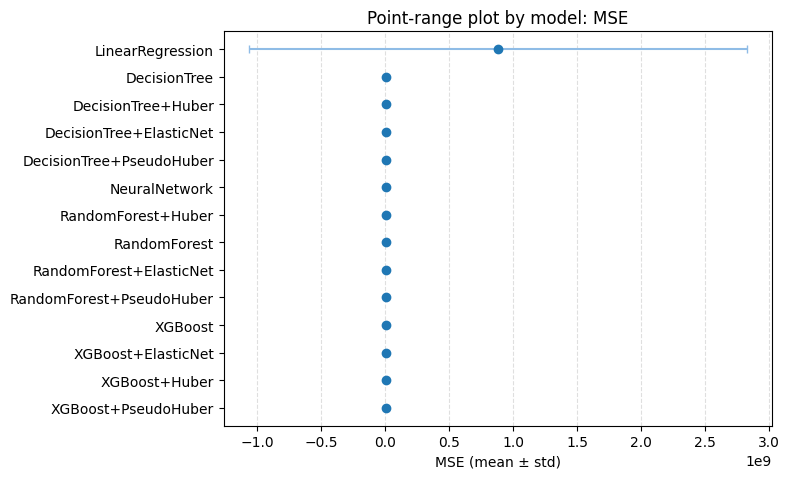

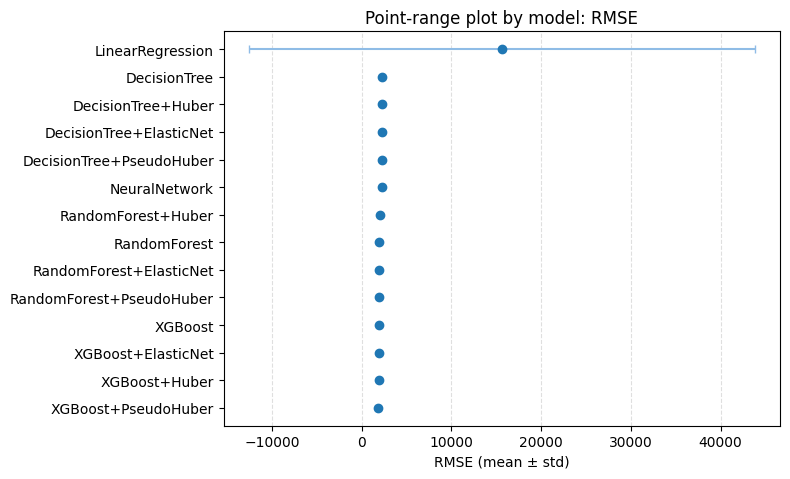

In [16]:
for metric in ["R2", "MAE", "MedAE", "MSE", "RMSE"]:
    is_ascending = metric != "R2" and metric != "NegMSE"
    fig = pm.plot_point_range(results_df=results, metric=metric, ascending=is_ascending)
    pm.save_fig(fig, f"point_range_{metric.lower()}")

### b. Display significance matrices for each metric

In [17]:
for metric in ["R2", "MAE", "MedAE", "MSE", "RMSE"]:
    display(exp.significance_matrix(metric=metric))

,metric,model_a,model_b,paired_t_p,wilcoxon_p,n_outer_folds
34,R2,DecisionTree+Huber,XGBoost+Huber,0.000006,0.0625,5
23,R2,DecisionTree+ElasticNet,XGBoost+Huber,0.000006,0.0625,5
11,R2,DecisionTree,XGBoost+Huber,0.000006,0.0625,5
44,R2,DecisionTree+PseudoHuber,XGBoost+Huber,0.000007,0.0625,5
35,R2,DecisionTree+Huber,XGBoost+PseudoHuber,0.000017,0.0625,5
...,...,...,...,...,...,...
13,R2,DecisionTree+ElasticNet,DecisionTree+Huber,0.542959,0.6250,5
88,R2,XGBoost+ElasticNet,XGBoost+Huber,0.562818,1.0000,5
82,R2,RandomForest+PseudoHuber,XGBoost+ElasticNet,0.644386,0.4375,5
37,R2,DecisionTree+PseudoHuber,NeuralNetwork,0.646608,0.8125,5


,metric,model_a,model_b,paired_t_p,wilcoxon_p,n_outer_folds
45,MAE,DecisionTree+PseudoHuber,XGBoost+PseudoHuber,0.000003,0.0625,5
24,MAE,DecisionTree+ElasticNet,XGBoost+PseudoHuber,0.000013,0.0625,5
12,MAE,DecisionTree,XGBoost+PseudoHuber,0.000013,0.0625,5
35,MAE,DecisionTree+Huber,XGBoost+PseudoHuber,0.000014,0.0625,5
34,MAE,DecisionTree+Huber,XGBoost+Huber,0.000015,0.0625,5
...,...,...,...,...,...,...
72,MAE,RandomForest+ElasticNet,XGBoost,0.752864,0.8125,5
66,MAE,RandomForest,XGBoost,0.761100,0.8125,5
71,MAE,RandomForest+ElasticNet,RandomForest+PseudoHuber,0.773775,0.6250,5
65,MAE,RandomForest,RandomForest+PseudoHuber,0.785470,0.6250,5


,metric,model_a,model_b,paired_t_p,wilcoxon_p,n_outer_folds
54,MedAE,LinearRegression,XGBoost+PseudoHuber,5.947622e-08,0.0625,5
36,MedAE,DecisionTree+PseudoHuber,LinearRegression,1.023155e-07,0.0625,5
3,MedAE,DecisionTree,LinearRegression,2.651664e-07,0.0625,5
15,MedAE,DecisionTree+ElasticNet,LinearRegression,3.413014e-07,0.0625,5
26,MedAE,DecisionTree+Huber,LinearRegression,4.238898e-07,0.0625,5
...,...,...,...,...,...,...
72,MedAE,RandomForest+ElasticNet,XGBoost,8.684899e-01,1.0000,5
66,MedAE,RandomForest,XGBoost,8.707102e-01,1.0000,5
71,MedAE,RandomForest+ElasticNet,RandomForest+PseudoHuber,9.581951e-01,0.8125,5
65,MedAE,RandomForest,RandomForest+PseudoHuber,9.584959e-01,0.8125,5


,metric,model_a,model_b,paired_t_p,wilcoxon_p,n_outer_folds
34,MSE,DecisionTree+Huber,XGBoost+Huber,0.000002,0.0625,5
23,MSE,DecisionTree+ElasticNet,XGBoost+Huber,0.000002,0.0625,5
11,MSE,DecisionTree,XGBoost+Huber,0.000002,0.0625,5
44,MSE,DecisionTree+PseudoHuber,XGBoost+Huber,0.000004,0.0625,5
41,MSE,DecisionTree+PseudoHuber,RandomForest+PseudoHuber,0.000013,0.0625,5
...,...,...,...,...,...,...
13,MSE,DecisionTree+ElasticNet,DecisionTree+Huber,0.551323,0.6250,5
88,MSE,XGBoost+ElasticNet,XGBoost+Huber,0.569842,1.0000,5
82,MSE,RandomForest+PseudoHuber,XGBoost+ElasticNet,0.623865,0.4375,5
37,MSE,DecisionTree+PseudoHuber,NeuralNetwork,0.653864,0.8125,5


,metric,model_a,model_b,paired_t_p,wilcoxon_p,n_outer_folds
23,RMSE,DecisionTree+ElasticNet,XGBoost+Huber,0.000002,0.0625,5
11,RMSE,DecisionTree,XGBoost+Huber,0.000002,0.0625,5
34,RMSE,DecisionTree+Huber,XGBoost+Huber,0.000002,0.0625,5
35,RMSE,DecisionTree+Huber,XGBoost+PseudoHuber,0.000003,0.0625,5
24,RMSE,DecisionTree+ElasticNet,XGBoost+PseudoHuber,0.000004,0.0625,5
...,...,...,...,...,...,...
13,RMSE,DecisionTree+ElasticNet,DecisionTree+Huber,0.522578,0.6250,5
88,RMSE,XGBoost+ElasticNet,XGBoost+Huber,0.553308,1.0000,5
37,RMSE,DecisionTree+PseudoHuber,NeuralNetwork,0.612397,0.8125,5
82,RMSE,RandomForest+PseudoHuber,XGBoost+ElasticNet,0.633065,0.4375,5


## 14. Save the best hyperparameters for each model to a JSON file

In [18]:
exp.save_best_params()

[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/best_params/best_params.json


## 15. SHAP analysis

### a. Populate Shap Analyzer with the Model Summary

In [19]:
shap_analyzer = exp.shap(models=model_summary)

### b. List all the Available Models

In [20]:
shap_analyzer.available_models()

['LinearRegression',
 'DecisionTree',
 'DecisionTree+ElasticNet',
 'DecisionTree+Huber',
 'DecisionTree+PseudoHuber',
 'RandomForest',
 'RandomForest+ElasticNet',
 'RandomForest+Huber',
 'RandomForest+PseudoHuber',
 'XGBoost',
 'XGBoost+ElasticNet',
 'XGBoost+Huber',
 'XGBoost+PseudoHuber',
 'NeuralNetwork']

### c. Generate and save SHAP beeswarm plots for all models

Computing SHAP for LinearRegression: 100%|██████████| 5/5 [00:00<00:00, 20.75it/s]


[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/shap/shap_beeswarm_linearregression.png


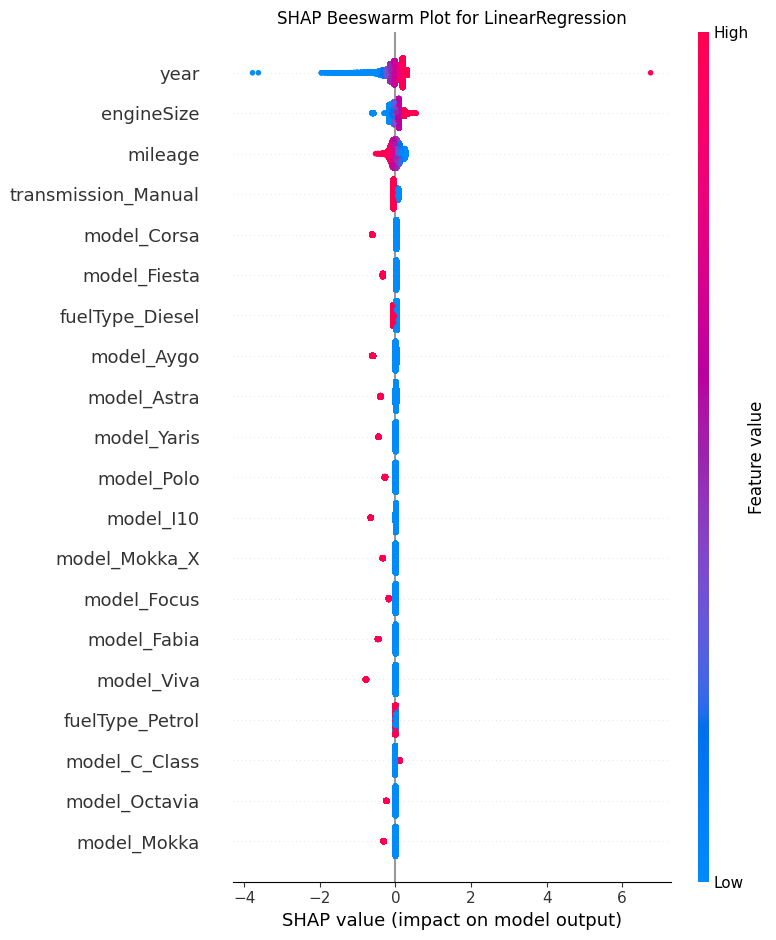

[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/shap/shap_GlobalImportance_linearregression.png


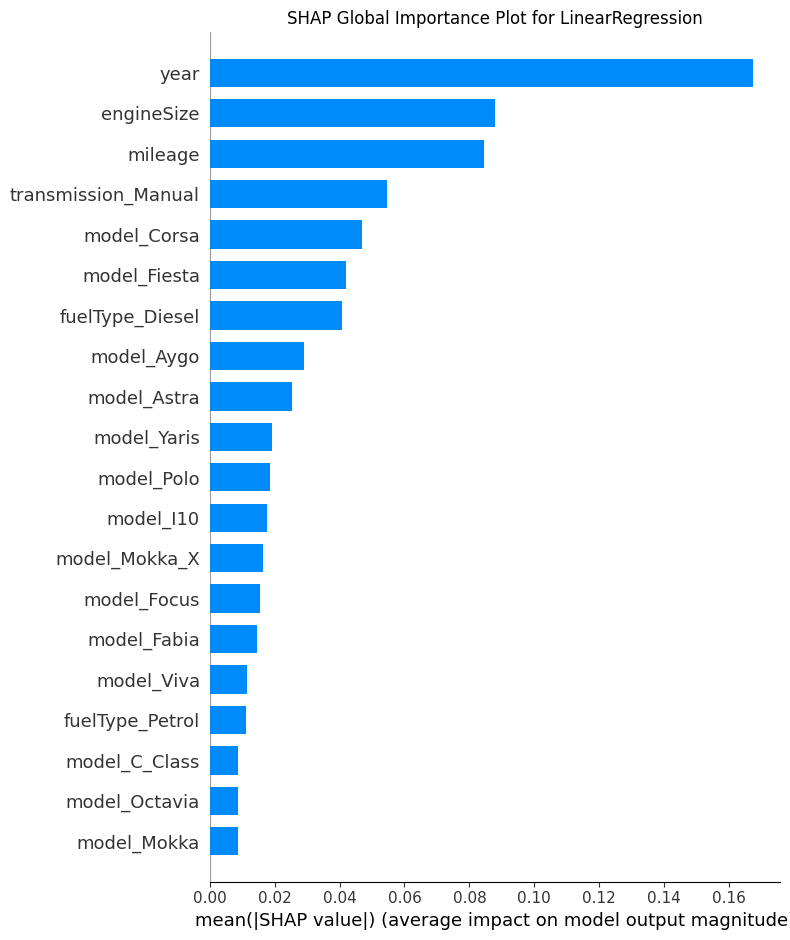

[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/shap/shap_Waterfall_linearregression.png


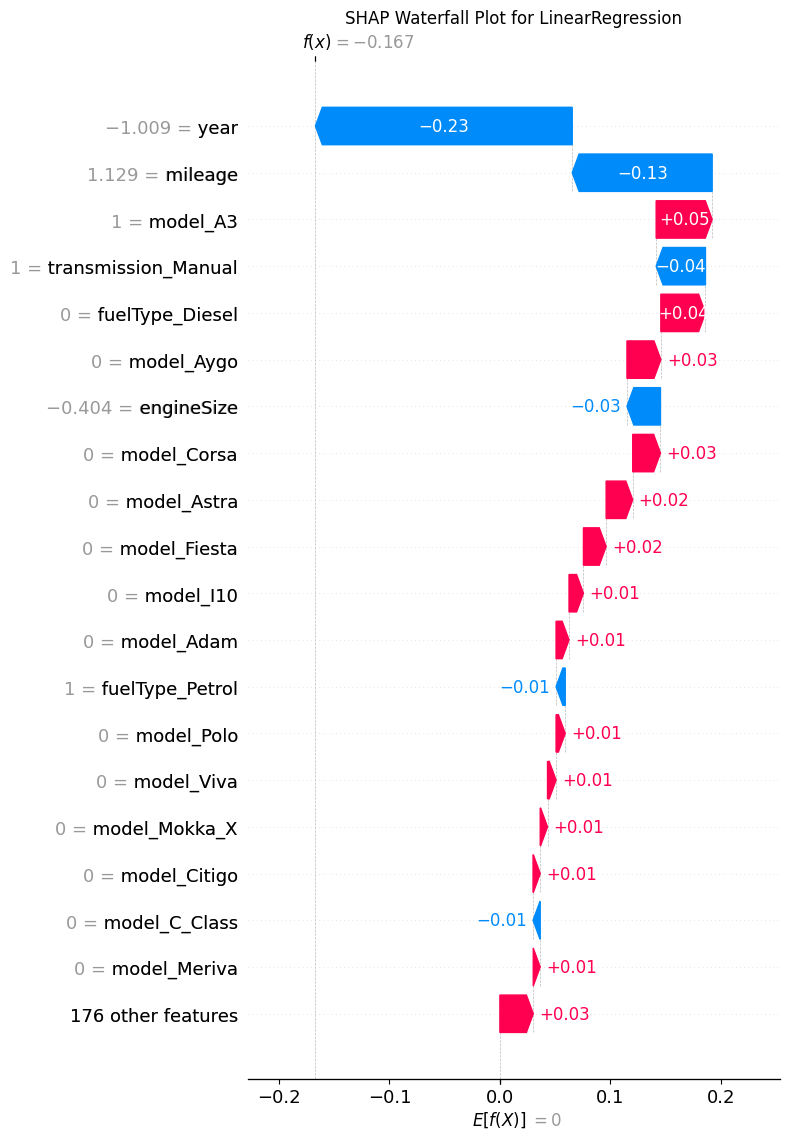

Computing SHAP for DecisionTree: 100%|██████████| 20/20 [05:22<00:00, 16.14s/it]


[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/shap/shap_beeswarm_decisiontree.png


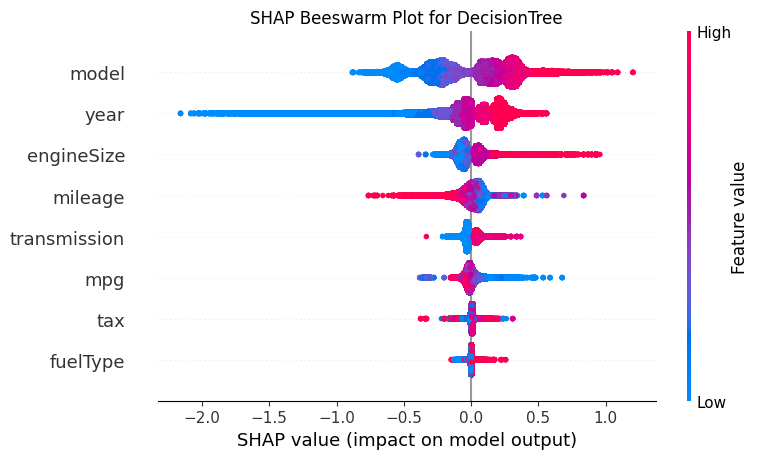

[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/shap/shap_GlobalImportance_decisiontree.png


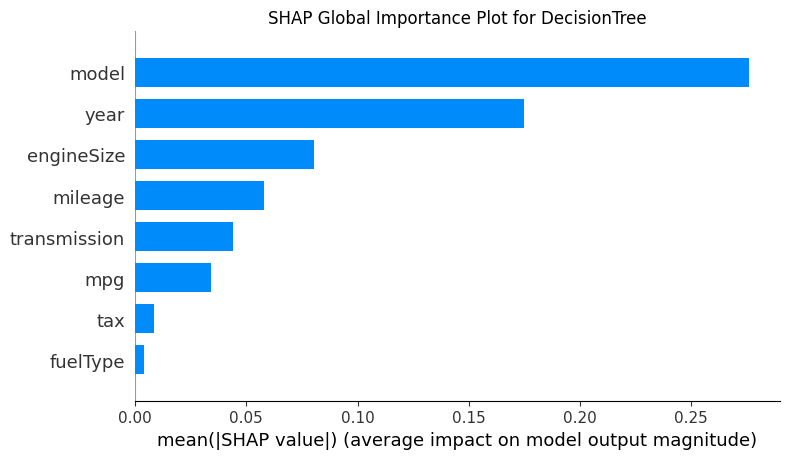

[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/shap/shap_Waterfall_decisiontree.png


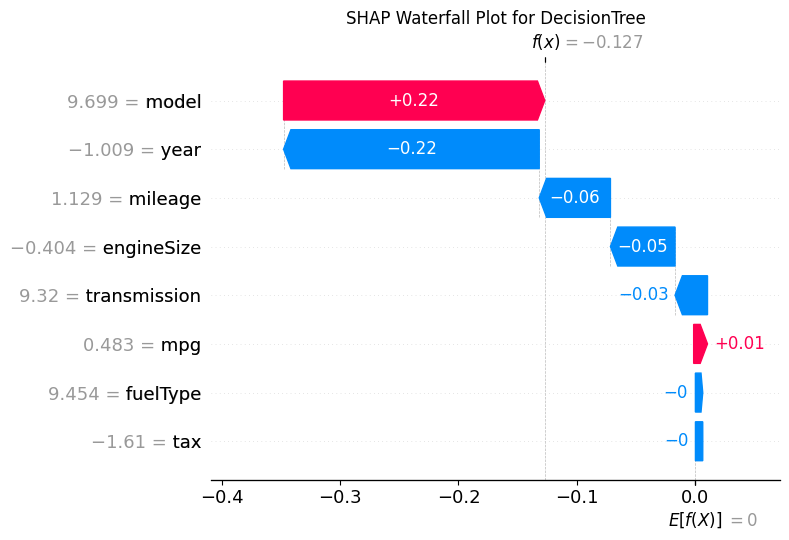

Computing SHAP for DecisionTree+ElasticNet: 100%|██████████| 5/5 [01:19<00:00, 15.83s/it]


[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/shap/shap_beeswarm_decisiontree+elasticnet.png


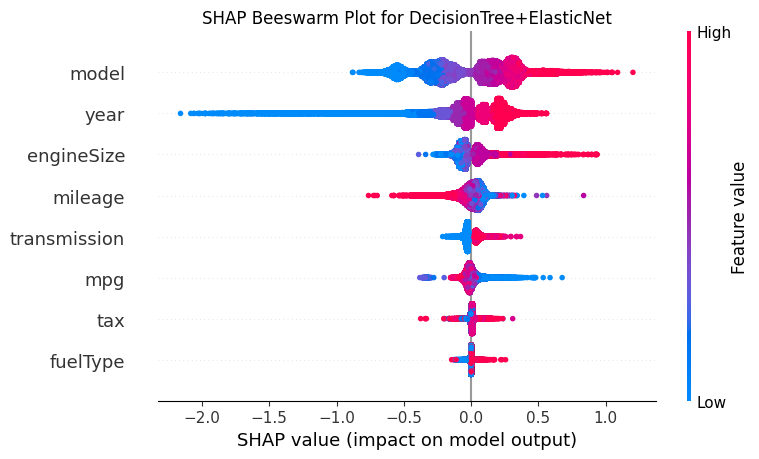

[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/shap/shap_GlobalImportance_decisiontree+elasticnet.png


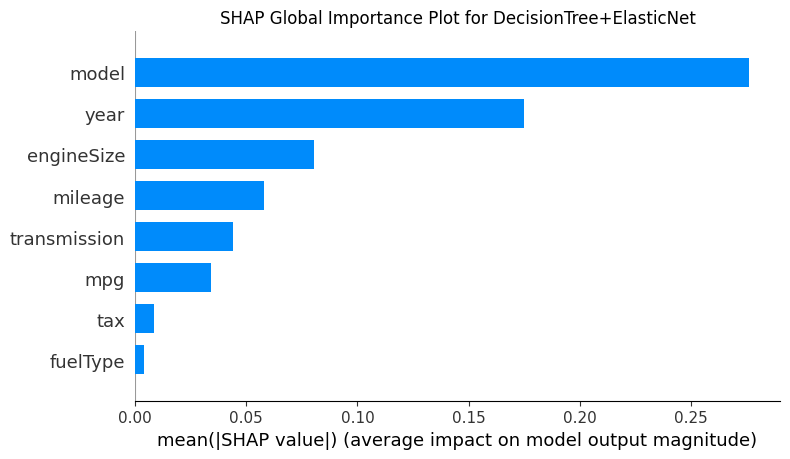

[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/shap/shap_Waterfall_decisiontree+elasticnet.png


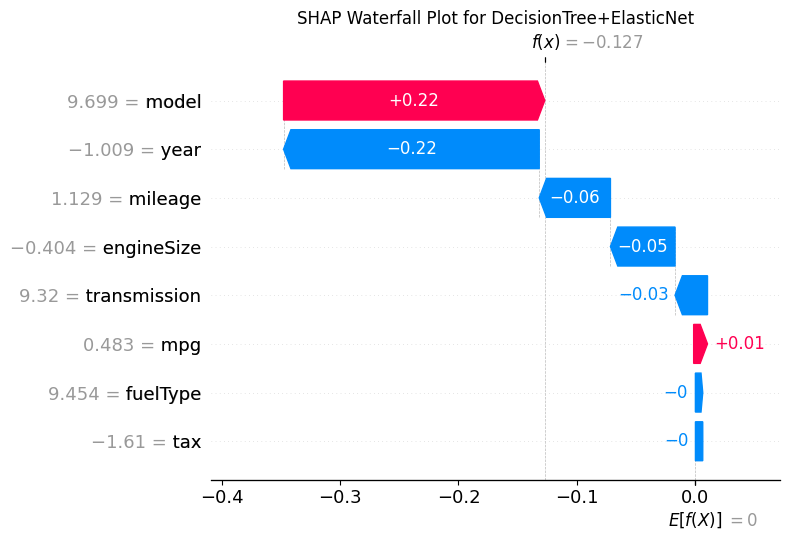

Computing SHAP for DecisionTree+Huber: 100%|██████████| 5/5 [01:19<00:00, 15.84s/it]


[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/shap/shap_beeswarm_decisiontree+huber.png


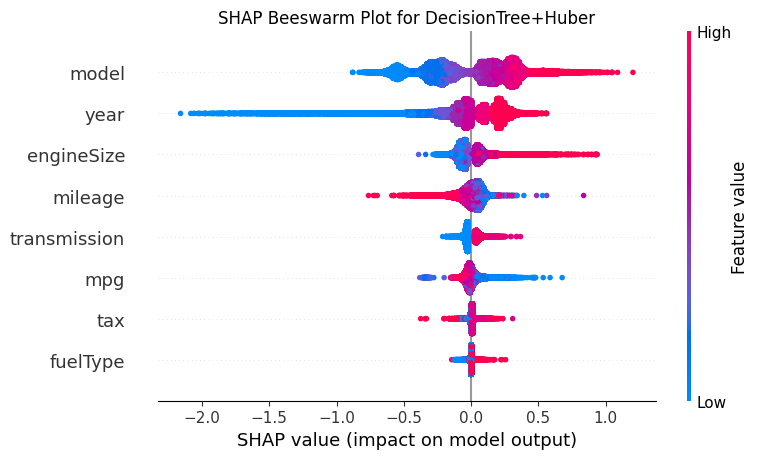

[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/shap/shap_GlobalImportance_decisiontree+huber.png


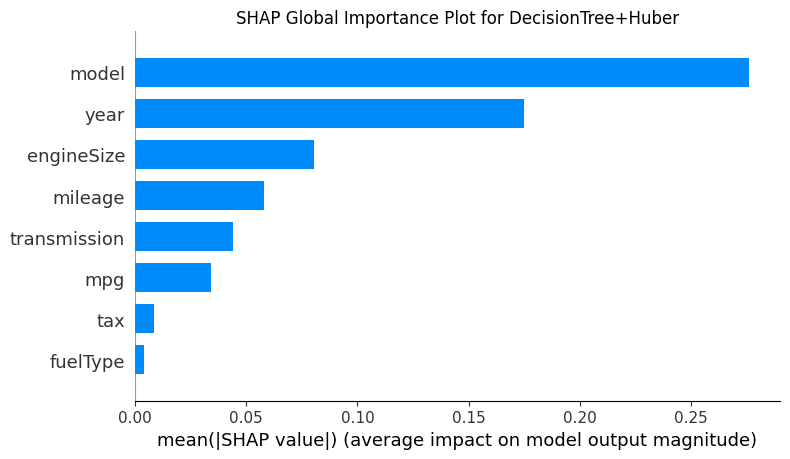

[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/shap/shap_Waterfall_decisiontree+huber.png


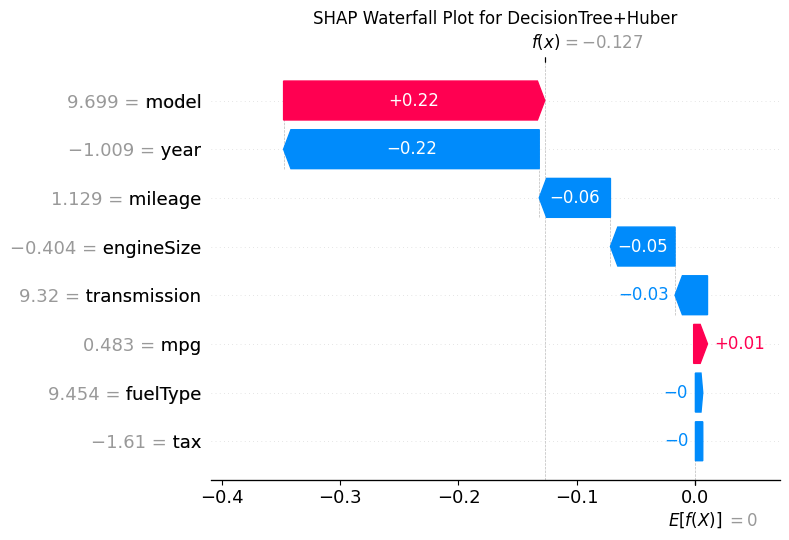

Computing SHAP for DecisionTree+PseudoHuber: 100%|██████████| 5/5 [01:12<00:00, 14.59s/it]


[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/shap/shap_beeswarm_decisiontree+pseudohuber.png


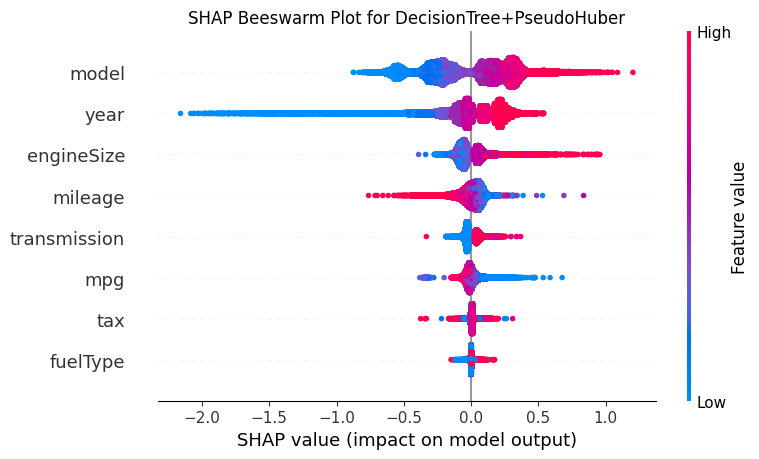

[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/shap/shap_GlobalImportance_decisiontree+pseudohuber.png


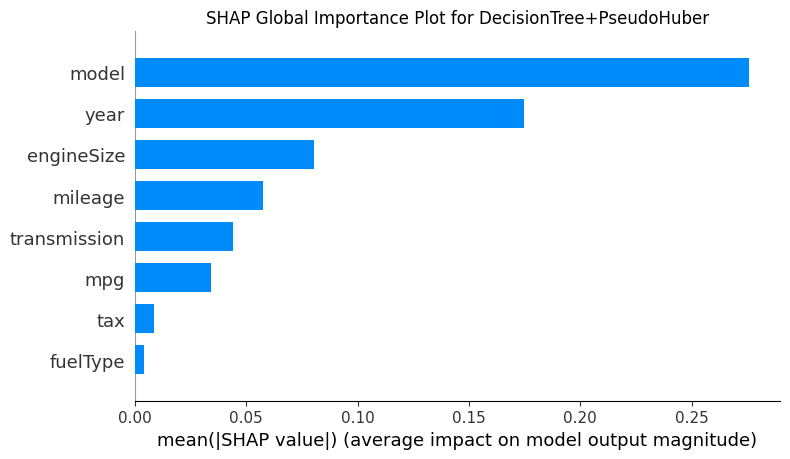

[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/shap/shap_Waterfall_decisiontree+pseudohuber.png


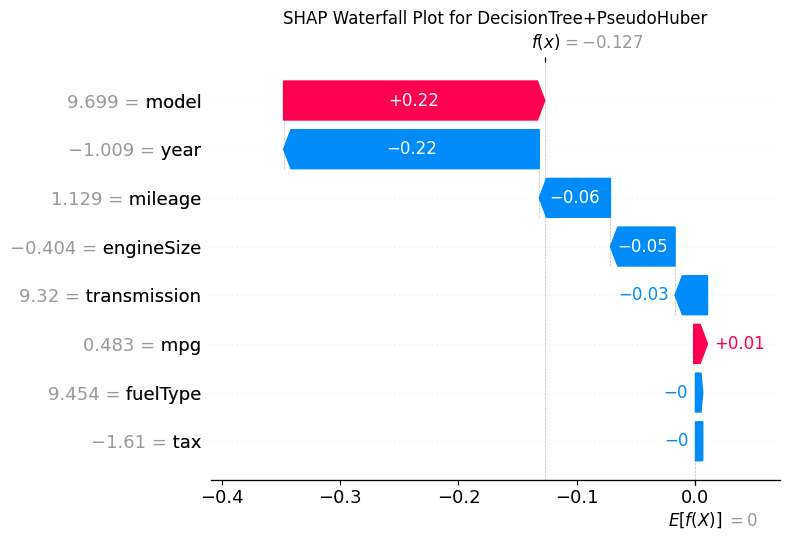

Computing SHAP for RandomForest:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
for m in shap_analyzer.available_models():
    shap_analyzer.beeswarm(m)